
# การอนุมานทางสถิติ

สถิติตามฤดูกาลอย่างง่าย inference workflow

ตัวอย่างนี้จะสาธิตวิธีการรัน inference workflow อย่างง่ายเพื่อสร้าง
forecast แล้วจึงบันทึกสถิติของข้อมูลนั้น มีบิวท์อินจำนวนหนึ่ง
สถิติมีอยู่ใน `earth2studio.statistics` แต่ที่นี่เราจะสาธิตวิธีการ
เพื่อกำหนดสถิติที่กำหนดเองและรัน inference

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์ของโมเดลพยากรณ์ที่มีมาให้ในระบบ
- วิธีสร้างแหล่งข้อมูลและออบเจ็กต์ IO
- สร้างสถิติที่กำหนดเอง
- วิธีรัน workflow พื้นฐานที่มีมาให้ในระบบ
- วิธีทำ post-processing กับผลลัพธ์


In [1]:
# /// script
# dependencies = [
#   "earth2studio[pangu,statistics] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "matplotlib",
# ]
# ///

## การสร้างเวิร์กโฟลว์ทางสถิติ

เริ่มต้นด้วยการสร้าง inference workflow แบบง่ายๆ เพื่อใช้งาน เราให้กำลังใจ
ผู้ใช้สามารถสำรวจและทดลองใช้ workflow แบบกำหนดเองของตนเองที่ยืมแนวคิดมา
workflow ในตัวภายใน :py:obj:`earth2studio.run` หรือตัวอย่าง

การสร้าง workflow ที่สามารถสรุปได้ทั่วไปของเราเองเพื่อใช้กับสถิตินั้นเป็นเรื่องง่ายเมื่อเราไว้วางใจ
อินเทอร์เฟซส่วนประกอบที่กำหนดใน Earth2Studio (ใช้การฉีดขึ้นต่อกัน) นี่เรา
สร้างวิธีการรันที่ยอมรับสิ่งต่อไปนี้:

- time: รายการ datetime / string ที่ต้องการใช้รัน inference
- nsteps: จำนวน forecast steps ที่ต้องการพยากรณ์
- prognostic: โมเดลพยากรณ์ที่เราเตรียมอินสแตนซ์ไว้แล้ว
- สถิติ: สถิติที่เรากำหนดเอง
- data: data source ที่เตรียมไว้แล้วสำหรับดึง initial conditions
- io: IOBackend

เราไม่ได้รัน ensemble inference workflow ที่นี่ แม้ว่าจะเป็นเรื่องปกติสำหรับสถิติทางสถิติ
inference. ดูตัวอย่าง ensemble สำหรับรายละเอียดเกี่ยวกับวิธีขยายตัวอย่างนี้เพื่อวัตถุประสงค์ดังกล่าว



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from datetime import datetime

import numpy as np
import onnxruntime as ort
import pandas as pd
from loguru import logger
from tqdm import tqdm

from earth2studio.data import DataSource, fetch_data
from earth2studio.io import IOBackend
from earth2studio.models.px import PrognosticModel
from earth2studio.statistics import Statistic
from earth2studio.utils.coords import map_coords
from earth2studio.utils.time import to_time_array

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)


def run_stats(
    time: list[str] | list[datetime] | list[np.datetime64],
    nsteps: int,
    nensemble: int,
    prognostic: PrognosticModel,
    statistic: Statistic,
    data: DataSource,
    io: IOBackend,
) -> IOBackend:
    """Simple statistics workflow

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        List of string, datetimes or np.datetime64
    nsteps : int
        Number of forecast steps
    nensemble : int
        Number of ensemble members to run inference for.
    prognostic : PrognosticModel
        Prognostic models
    statistic : Statistic
        Custom statistic to compute and write to IO.
    data : DataSource
        Data source
    io : IOBackend
        IO object

    Returns
    -------
    IOBackend
        Output IO object
    """
    logger.info("Running simple statistics workflow!")
    # Pangu runs through ONNX Runtime, so CUDA is only usable when ORT has a CUDA provider.
    ort_providers = ort.get_available_providers()
    if torch.cuda.is_available() and "CUDAExecutionProvider" in ort_providers:
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
        if torch.cuda.is_available():
            logger.warning(
                "CUDA is available, but ONNX Runtime has no CUDAExecutionProvider; "
                "running Pangu on CPU."
            )
    logger.info(f"Inference device: {device}")
    prognostic = prognostic.to(device)
    # ดึงข้อมูลจากแหล่งข้อมูลและโหลดลงในอุปกรณ์
    time = to_time_array(time)
    x, coords = fetch_data(
        source=data,
        time=time,
        lead_time=prognostic.input_coords()["lead_time"],
        variable=prognostic.input_coords()["variable"],
        device=device,
    )
    logger.success(f"Fetched data from {data.__class__.__name__}")

    # ตั้งค่า IO Backend
    total_coords = coords.copy()
    output_coords = prognostic.output_coords(prognostic.input_coords())
    total_coords["lead_time"] = np.asarray(
        [output_coords["lead_time"] * i for i in range(nsteps + 1)]
    ).flatten()
    # ลบมิติที่ลดลงออกจากสถิติ
    for d in statistic.reduction_dimensions:
        total_coords.pop(d, None)

    io.add_array(total_coords, str(statistic))

    # แผนที่ lat และ lon หากจำเป็น
    x, coords = map_coords(x, coords, prognostic.input_coords())

    # สร้างตัววนซ้ำเชิงพยากรณ์
    model = prognostic.create_iterator(x, coords)

    logger.info("Inference starting!")
    with tqdm(total=nsteps + 1, desc="Running inference") as pbar:
        for step, (x, coords) in enumerate(model):
            s, coords = statistic(x, coords)
            io.write(s, coords, str(statistic))
            pbar.update(1)
            if step == nsteps:
                break

    logger.success("Inference complete")
    return io

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การเตรียมองค์ประกอบ
ด้วยการกำหนด workflow ทางสถิติ ตอนนี้เราจำเป็นต้องสร้างแต่ละองค์ประกอบ

เราจำเป็นต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ Pangu 24 ชั่วโมงรุ่น :py:class:`earth2studio.models.px.Pangu24` ในตัว
- สถิติ: เรากำหนดสถิติของเราเอง: Southern Oscillation Index (SOI)
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้าน NetCDF4 :py:class:`earth2studio.io.NetCDF4Backend`



In [3]:
from collections import OrderedDict

import fsspec
import numpy as np
import torch

from earth2studio.data import GFS
from earth2studio.io import NetCDF4Backend
from earth2studio.models.px import Pangu24
from earth2studio.utils.type import CoordSystem

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = Pangu24.load_default_package()
model = Pangu24.load_model(package)

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = NetCDF4Backend(
    file_name="outputs/soi.nc",
    backend_kwargs={"mode": "w"},
)


# สร้างสถิติที่กำหนดเอง
class SOI:
    """Custom metric calculation the Southern Oscillation Index.

    SOI = ( standardized_tahiti_slp - standardized_darwin_slp ) / soi_normalization

    soi_normalization = std( historical ( standardized_tahiti_slp - standardized_darwin_slp ) )

    standardized_*_slp = (*_slp - climatological_mean_*_slp) / climatological_std_*_slp

    Note
    ----
    __str__
        Name that will be applied to the output of this statistic, primarily for IO purposes.
    reduction_dimensions
        Dimensions that this statistic reduces over. This is used to help automatically determine
        the output coordinates, primarily used for IO purposes.
    """

    def __str__(self) -> str:
        return "soi"

    def __init__(
        self,
    ):
        # อ่านข้อมูลตาฮิติและดาร์วิน SLP
        url = "https://data.longpaddock.qld.gov.au/SeasonalClimateOutlook/SouthernOscillationIndex/SOIDataFiles/DailySOI1933-1992Base.txt"
        with fsspec.open(url, "r") as f:
            ds = pd.read_csv(f, sep=r"\s+")
        dates = pd.date_range("1999-01-01", freq="d", periods=len(ds))
        ds["date"] = dates
        ds = ds.set_index("date")
        ds = ds.drop(["Year", "Day", "SOI"], axis=1)
        ds = ds.rolling(30, min_periods=1).mean().dropna()

        self.climatological_means = torch.tensor(
            ds.groupby(ds.index.month).mean().to_numpy(), dtype=torch.float32
        )
        self.climatological_std = torch.tensor(
            ds.groupby(ds.index.month).std().to_numpy(), dtype=torch.float32
        )

        standardized = ds.groupby(ds.index.month).transform(
            lambda x: (x - x.mean()) / x.std()
        )
        diff = standardized["Tahiti"] - standardized["Darwin"]

        self.normalization = torch.tensor(
            diff.groupby(ds.index.month).std().to_numpy(), dtype=torch.float32
        )

        self.tahiti_coords = {
            "variable": np.array(["msl"]),
            "lat": np.array([-17.65]),
            "lon": np.array([210.57]),
        }
        self.darwin_coords = {
            "variable": np.array(["msl"]),
            "lat": np.array([-12.46]),
            "lon": np.array([130.84]),
        }

        self.reduction_dimensions = list(self.tahiti_coords)

    def __call__(
        self, x: torch.Tensor, coords: CoordSystem
    ) -> tuple[torch.Tensor, CoordSystem]:
        """Computes the SOI given an input.

        coords must be a superset of both

        tahiti_coords = {
            'variable': np.array(['msl']),
            'lat': np.array([-17.65]),
            'lon': np.array([210.57])
        }

        and

        darwin_coords = {
            'variable': np.array(['msl']),
            'lat': np.array([-12.46]),
            'lon': np.array([130.84])
        }

        So make sure that the model chosen predicts the `msl` variable.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor
        coords : CoordSystem
            coordinate system belonging to the input tensor.

        Returns
        -------
        tuple[torch.Tensor, CoordSystem]
            Returns the SOI and appropriate coordinate system.
        """
        tahiti, _ = map_coords(x, coords, self.tahiti_coords)
        darwin, _ = map_coords(x, coords, self.darwin_coords)

        tahiti = tahiti.squeeze(-3, -2, -1) / 100.0
        darwin = darwin.squeeze(-3, -2, -1) / 100.0
        output_coords = OrderedDict(
            {k: v for k, v in coords.items() if k not in self.reduction_dimensions}
        )

        # รับพิกัดเวลา
        times = coords["time"].reshape(-1, 1) + coords["lead_time"].reshape(1, -1)
        months = torch.broadcast_to(
            torch.as_tensor(
                [pd.Timestamp(t).month for t in times.flatten()],
                device=tahiti.device,
                dtype=torch.int32,
            ).reshape(times.shape),
            tahiti.shape,
        )

        cm = self.climatological_means.to(tahiti.device)
        cs = self.climatological_std.to(tahiti.device)
        norm = self.normalization.to(tahiti.device)

        tahiti_std_anomaly = (tahiti - cm[months, 0]) / cs[months, 0]
        darwin_std_anomaly = (tahiti - cm[months, 1]) / cs[months, 1]

        return (tahiti_std_anomaly - darwin_std_anomaly) / norm[months], output_coords


soi = SOI()

## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม
เราจำลองวิถีการเคลื่อนที่ของเวลา 60 ก้าว หรือ 2 เดือนโดยใช้ Pangu24



In [4]:
nsteps = 60
nensemble = 1
io = run_stats(["2022-01-01"], nsteps, nensemble, model, soi, data, io)

2026-04-25 19:58:30.977 | INFO     | __main__:run_stats:60 - Running simple statistics workflow!
2026-04-25 19:58:30.978 | INFO     | __main__:run_stats:72 - Inference device: cuda


Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-04-25 19:58:36.403 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 201416483-580864
2026-04-25 19:58:36.420 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 150888816-767600
2026-04-25 19:58:36.429 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 301178894-856992
2026-04-25 19:58:36.438 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 197589080-1153817
2026-04-25 19:58:36.447 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 238232118-730356
2026-04-25 19:58:36.456 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-04-25 19:58:36.580 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 264633312-547872
2026-04-25 19:58:36.589 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 342364395-942176
2026-04-25 19:58:36.598 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 156987362-832146


...

2026-04-25 19:58:36.988 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 211657731-595750
2026-04-25 19:58:36.996 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 334667042-859385
2026-04-25 19:58:37.006 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 207773671-1144304


Fetching GFS data: 100%|██████████| 69/69 [00:00<00:00, 107.79it/s]


2026-04-25 19:58:37.015 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 259084713-722805
2026-04-25 19:58:37.024 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 341434010-930385
2026-04-25 19:58:37.034 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 156114459-872903
2026-04-25 19:58:37.102 | SUCCESS  | __main__:run_stats:83 - Fetched data from GFS
2026-04-25 19:58:37.103 | INFO     | __main__:run_stats:103 - Inference starting!


Running inference: 100%|██████████| 61/61 [04:24<00:00,  4.34s/it]

2026-04-25 20:03:01.779 | SUCCESS  | __main__:run_stats:112 - Inference complete


## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ

สังเกตว่าฟังก์ชัน NetCDF IO มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่เก็บไว้



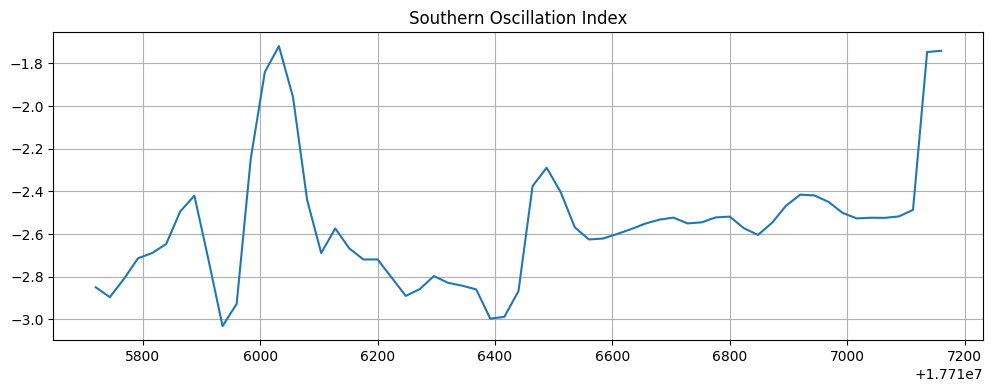

In [5]:
import matplotlib.pyplot as plt

times = io["time"][:].flatten() + io["lead_time"][:].flatten()

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(times, io["soi"][:].flatten())
ax.set_title("Southern Oscillation Index")
ax.grid("on")

plt.savefig("outputs/07_southern_oscillation_index_prediction_2022.png")
io.close()